# Numerical Simulation Laboratory - Notebook 3

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

## Excercise 03.1

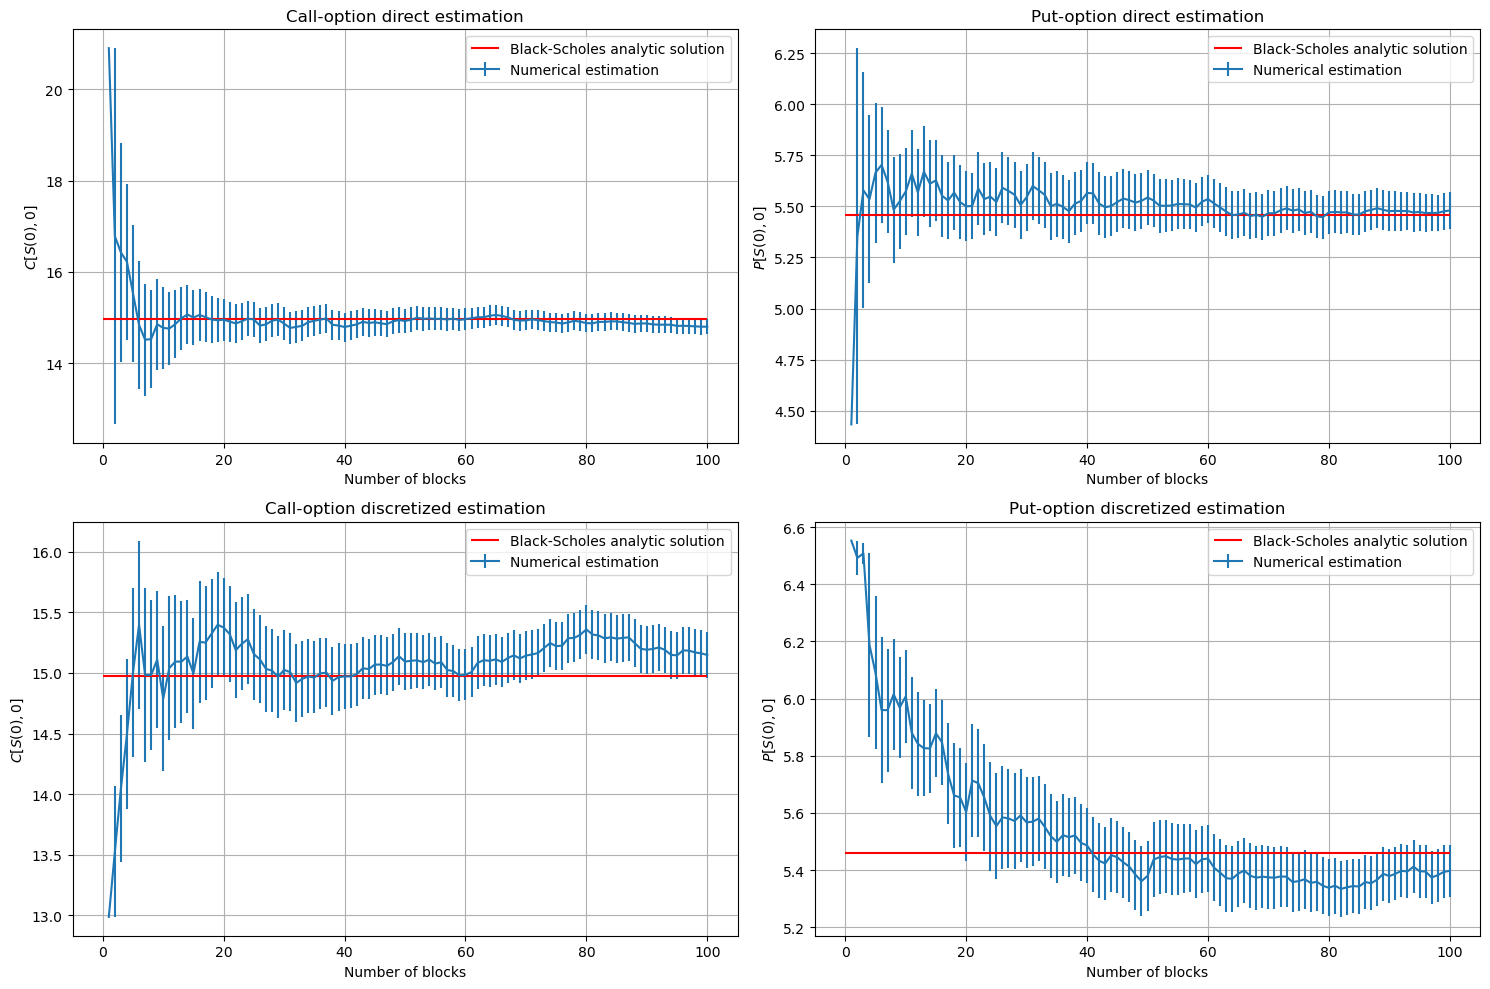

In [2]:
filenames = ["call_direct.out", "put_direct.out", "call_discrete.out", "put_discrete.out"]
titles = ["Call-option direct estimation", "Put-option direct estimation", "Call-option discretized estimation", "Put-option discretized estimation"]
y_labels = [r"$C[S(0),0]$", r"$P[S(0),0]$"]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

black_scholes = [14.975790778311286, 5.4595325819072364]

for i, file in enumerate(filenames):
    blocks, averages, errors = np.loadtxt(f"../03-Exercises/OUTPUT/{file}", unpack=True)
    
    axs[i].errorbar(blocks, averages, yerr=errors, label="Numerical estimation")
    axs[i].hlines(black_scholes[i%2], 0., blocks[-1], color="red", label="Black-Scholes analytic solution")
    
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Number of blocks")
    axs[i].set_ylabel(y_labels[i%2])
    
    axs[i].legend()
    axs[i].grid()
    
fig.tight_layout();

Both the direct and the discretized estimation accurately converge to the value predicted by the Black-Scholes analytical solution. By changing the seed we can see that neither of the two methods performs systematically better than the other, which shows that with a small enough time discretization the two estimation are equivalent. The advantage of the direct method is that it is less computationally demanding: for example in this exercise it requires 100 times less operations for the same results.